In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import random
import scipy
import time

### To do for code

$f(\kappa, q, \sigma) = \kappa * M_1 + q * M_2 + \sigma * M_3$ (easiest emulator)

In [50]:
data = pd.read_csv('gpe_self_consistent_energies_5x5x5.csv')

In [126]:
def get_train_test_split(data, n_samples, cutoff):
    temp_order = np.arange(0, n_samples, 1, dtype=int)
    random.shuffle(temp_order)
    train_k = np.array([data['kappa'][temp_order[i]] for i in range(cutoff)])
    train_q = np.array([data['q'][temp_order[i]] for i in range(cutoff)])
    train_sigma = np.array([data['sigma'][temp_order[i]] for i in range(cutoff)])
    train_e = np.array([data['E'][temp_order[i]] for i in range(cutoff)])
    val_k = np.array([data['kappa'][temp_order[i+cutoff]] for i in range(len(data)-cutoff)])
    val_q = np.array([data['q'][temp_order[i+cutoff]] for i in range(len(data)-cutoff)])
    val_sigma = np.array([data['sigma'][temp_order[i+cutoff]] for i in range(len(data)-cutoff)])
    val_e = np.array([data['E'][temp_order[i+cutoff]] for i in range(len(data)-cutoff)])
    return train_k, train_q, train_sigma, train_e, val_k, val_q, val_sigma, val_e

def mult(arr, mat):
    """
    Multiplies array with matrices
    """
    new_mats = []
    for i in arr:
        new_mats.append(i*mat)
    return np.array(new_mats)

def H_mat(n_bases, x, params):
    """
    Build matrix equation 
    
    n_bases: number of dimensions of matrices
    x: set of matrix elements

    returns: full matrix
    """
    n_params = len(params)
    H = np.zeros((n_bases,n_bases)) # Total Hamiltonian
    H_next = np.zeros((n_params, n_bases, n_bases))# symmetric matrix components of the Hamiltonian
    tmp = 0
        
    # Creating the symmetric matrix from the given matrix elements
    for k in range(n_params):
        for i in range(n_bases):
            for j in range(i, n_bases):
                H_next[k][i][j] = x[tmp]
                H_next[k][j][i] = H_next[k][i][j]
                tmp += 1
    
    # Adding the symmetric matrices to the final Hamiltonian
    counter = 0
    for i in range(n_params):
        H = H + mult(params[i,:], H_next[counter])
        counter += 1
    return H

def find_e(n_bases, x, params):
    """
    Find lowest eigenvalue
    
    Lecs: Operator LECs
    n_bases: number of dimensions of the parametric matrix model
    x: set of PMM matrix elements
    
    returns: all eigenvalues, the lowest is the energy we fit for
    """
    H = H_mat(n_bases, x, params)
    ev, ef = np.linalg.eigh(H)
    return ev


# Fit cost function
def cost_function(x, params, BE_training, n_bases): # rms cost function
    BE_predict = find_e(n_bases, x, params)

    cost = sum((abs(np.array(BE_predict[:,0])-np.array(BE_training))) ** 2)

    return cost

# Fit PMM
def get_pmm(coeffs, solutions, n_bases, n_train):
    """
    n_tests: array of 1 through number of test values, last number should be less than length of train_order
    n_lecs: the number of LECs that have matrices associated
    """
    n_params = len(coeffs)
    n_pred = int(n_params*n_bases*(n_bases+1)/2) # number of parameters to find in PMM
    x_temp = np.array([random.randint(-50,50) for i in range(n_pred)]) # initial guess for PMM parameters
    bounds = [(-500, 500)] * len(x_temp)
    res_da = scipy.optimize.dual_annealing(cost_function, bounds, args=(coeffs[:,:n_train], solutions[:n_train], n_bases), x0=x_temp)
    return res_da['x'], res_da['fun']

In [108]:
n_pred = int(3*2*(2+1)/2) # number of parameters to find in PMM
x_temp = np.array([random.randint(-50,50) for i in range(n_pred)]) # initial guess for PMM parameters

In [154]:
train_k, train_q, train_sigma, train_e, val_k, val_q, val_sigma, val_e = get_train_test_split(data, len(data['E']), 60)
x = np.array([train_k, train_q, train_sigma])
n_train = 60
params = np.array([train_k, train_q, train_sigma])
x_pmm_output, errors = get_pmm(params, train_e, 2, n_train)


In [155]:
params_val = np.array([val_k, val_q, val_sigma])
evs = find_e(2, x_pmm_output, params_val)

In [171]:
q_fixed = np.ones(100)
sigma_fixed = 1.75*np.ones(100)
kappa_fixed = 1.75*np.ones(100)
q = np.linspace(-2.0, 2.0, 100)
sigma = np.linspace(0.5, 3.0, 100)
kappa = np.linspace(0.5, 3.0, 100)
params_vary_kappa = np.array([kappa, q_fixed, sigma_fixed])
params_vary_q = np.array([kappa_fixed, q, sigma_fixed])
params_vary_sigma = np.array([kappa_fixed, q_fixed, sigma])
evs_vary_kappa = find_e(2, x_pmm_output, params_vary_kappa)
evs_vary_q = find_e(2, x_pmm_output, params_vary_q)
evs_vary_sigma = find_e(2, x_pmm_output, params_vary_sigma)

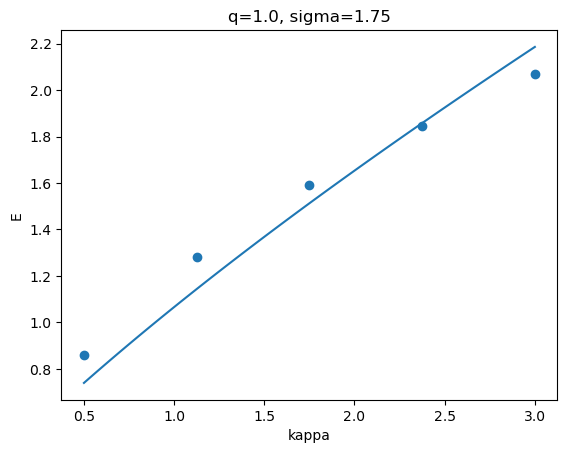

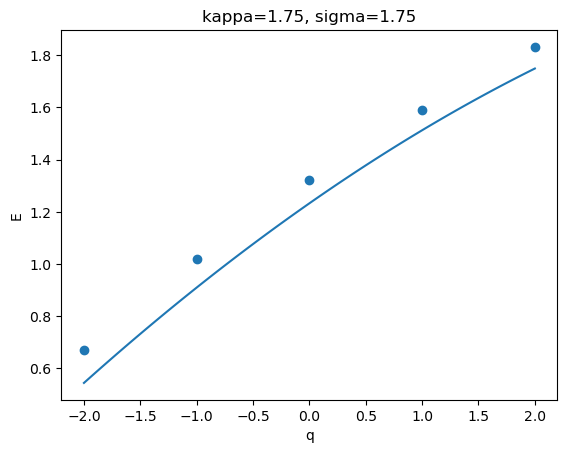

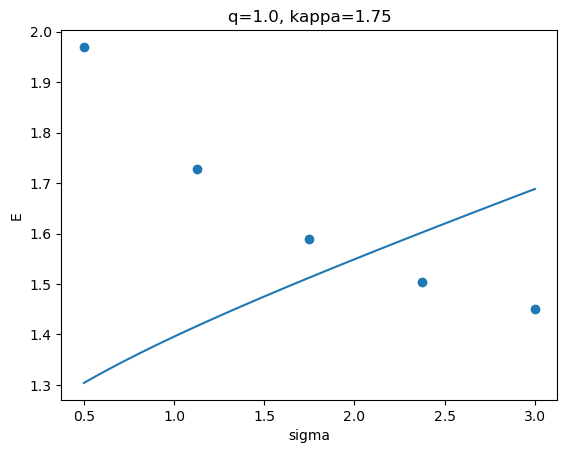

In [173]:
mask = (data['q'] == 1.0) & (data['sigma'] == 1.75)
plt.plot(kappa, evs_vary_kappa[:,0])
plt.scatter(data['kappa'][mask], data['E'][mask])
plt.title('q=1.0, sigma=1.75')
plt.xlabel('kappa')
plt.ylabel('E')
plt.show()

mask = (data['kappa'] == 1.75) & (data['sigma'] == 1.75)
plt.plot(q, evs_vary_q[:,0])
plt.scatter(data['q'][mask], data['E'][mask])
plt.title('kappa=1.75, sigma=1.75')
plt.xlabel('q')
plt.ylabel('E')
plt.show()

mask = (data['q'] == 1.0) & (data['kappa'] == 1.75)
plt.plot(sigma, evs_vary_sigma[:,0])
plt.scatter(data['sigma'][mask], data['E'][mask])
plt.title('q=1.0, kappa=1.75')
plt.xlabel('sigma')
plt.ylabel('E')
plt.show()